In [1]:
# Imports and setup

import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Add src/ to Python path so we can import our modules
notebook_dir = Path.cwd()
project_root = notebook_dir.parent  # assignment_2/
sys.path.insert(0, str(project_root / "src"))

# Verify paths
print("Notebook dir:", notebook_dir)
print("Project root:", project_root)
print("Data dir:    ", project_root / "data" / "raw")


Notebook dir: c:\Users\raula\Desktop\renewable\RES-Assignments\assignment_2\notebooks
Project root: c:\Users\raula\Desktop\renewable\RES-Assignments\assignment_2
Data dir:     c:\Users\raula\Desktop\renewable\RES-Assignments\assignment_2\data\raw


In [2]:
# Load raw data and sanity-check

from data_loader import load_all

raw = load_all(data_dir=project_root / "data" / "raw")

print("Wind capacity factor:")
print(f"  shape: {raw.wind_cf.shape}, range: [{raw.wind_cf.min():.3f}, {raw.wind_cf.max():.3f}], mean: {raw.wind_cf.mean():.3f}")
print(f"  index: {raw.wind_cf.index[0]} → {raw.wind_cf.index[-1]}")
print()

print("DA prices (EUR/MWh):")
print(f"  shape: {raw.da_prices.shape}, range: [{raw.da_prices.min():.2f}, {raw.da_prices.max():.2f}], mean: {raw.da_prices.mean():.2f}")
print(f"  index: {raw.da_prices.index[0]} → {raw.da_prices.index[-1]}")
print()

print("Imbalance:")
print(f"  shape: {raw.imbalance.shape}")
print(f"  columns: {list(raw.imbalance.columns)}")
print(f"  index: {raw.imbalance.index[0]} → {raw.imbalance.index[-1]}")
print()
print(raw.imbalance.describe())

Wind capacity factor:
  shape: (8760,), range: [0.000, 0.939], mean: 0.265
  index: 2024-01-01 00:00:00+00:00 → 2024-12-30 23:00:00+00:00

DA prices (EUR/MWh):
  shape: (8760,), range: [-59.96, 936.31], mean: 70.97
  index: 2024-01-01 00:00:00 → 2024-12-30 23:00:00

Imbalance:
  shape: (8760, 3)
  columns: ['mFRRUpActBal', 'mFRRDownActBal', 'ImbalanceMWh']
  index: 2024-01-01 00:00:00 → 2024-12-30 23:00:00

       mFRRUpActBal  mFRRDownActBal  ImbalanceMWh
count   8760.000000     8760.000000   8760.000000
mean       5.860360        9.814498   -121.936998
std       27.773364       29.500083    215.530390
min        0.000000        0.000000  -1265.000000
25%        0.000000        0.000000   -220.749996
50%        0.000000        0.000000   -105.649997
75%        0.000000        0.000000    -18.200001
max      537.000000      349.250000   1128.599976


In [3]:
# Build scenarios and sanity-check

from scenario_generation import build_scenarios, estimate_imbalance_p

p_hat = estimate_imbalance_p(raw.imbalance)
print(f"Estimated Bernoulli p = {p_hat:.3f}")
print()

S = build_scenarios(raw, n_wind=20, n_price=20, n_imb=4, P_nom=500.0, master_seed=42)

print(f"ScenarioSet:")
print(f"  n_scenarios = {S.n_scenarios}")
print(f"  n_hours     = {S.n_hours}")
print(f"  P_nom       = {S.P_nom} MW")
print(f"  prob/scen   = {S.probabilities[0]:.6f}  (sum = {S.probabilities.sum():.4f})")
print()

print("Wind production [MW]:")
print(f"  shape: {S.wind.shape}")
print(f"  range: [{S.wind.min():.1f}, {S.wind.max():.1f}]")
print(f"  mean:  {S.wind.mean():.1f}")
print()

print("DA prices [EUR/MWh]:")
print(f"  shape: {S.price_da.shape}")
print(f"  range: [{S.price_da.min():.2f}, {S.price_da.max():.2f}]")
print(f"  mean:  {S.price_da.mean():.2f}")
print()

print("Imbalance (binary):")
print(f"  shape: {S.imbalance.shape}")
print(f"  unique values: {np.unique(S.imbalance)}")
print(f"  fraction of '1' (deficit hours): {S.imbalance.mean():.3f}")

Estimated Bernoulli p = 0.344

ScenarioSet:
  n_scenarios = 1600
  n_hours     = 24
  P_nom       = 500.0 MW
  prob/scen   = 0.000625  (sum = 1.0000)

Wind production [MW]:
  shape: (1600, 24)
  range: [7.8, 420.5]
  mean:  140.9

DA prices [EUR/MWh]:
  shape: (1600, 24)
  range: [-40.77, 340.00]
  mean:  78.44

Imbalance (binary):
  shape: (1600, 24)
  unique values: [0 1]
  fraction of '1' (deficit hours): 0.312


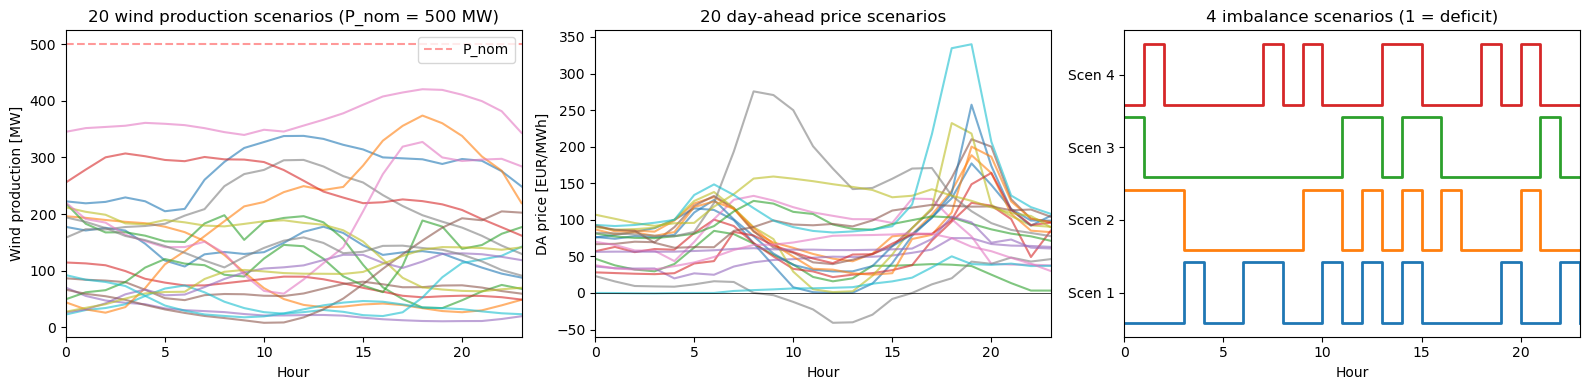

In [4]:
# Scenarios plot
 
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
hours = np.arange(24)

# Wind production scenarios (the 20 unique wind trajectories)
for w in S.wind_unique:
    axes[0].plot(hours, w, alpha=0.6)
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Wind production [MW]")
axes[0].set_title(f"20 wind production scenarios (P_nom = {S.P_nom:.0f} MW)")
axes[0].set_xlim(0, 23)
axes[0].axhline(S.P_nom, color="red", linestyle="--", alpha=0.4, label="P_nom")
axes[0].legend()

# DA price scenarios (the 20 unique price trajectories)
for p in S.price_unique:
    axes[1].plot(hours, p, alpha=0.6)
axes[1].set_xlabel("Hour")
axes[1].set_ylabel("DA price [EUR/MWh]")
axes[1].set_title("20 day-ahead price scenarios")
axes[1].set_xlim(0, 23)
axes[1].axhline(0, color="black", linewidth=0.5)

# Imbalance scenarios (the 4 unique binary trajectories)
for i, imb in enumerate(S.imbalance_unique):
    axes[2].step(hours, imb + i * 1.2, where="post", linewidth=2)
axes[2].set_xlabel("Hour")
axes[2].set_yticks([0.5 + i * 1.2 for i in range(4)])
axes[2].set_yticklabels([f"Scen {i+1}" for i in range(4)])
axes[2].set_title("4 imbalance scenarios (1 = deficit)")
axes[2].set_xlim(0, 23)

plt.tight_layout()
plt.show()

# Task 1.1

In [5]:
# Task 1.1 — One-price offering strategy

from task1_1_offering_oneprice import OneprcInputData, StochasticOfferingOnePrice
data_1p = OneprcInputData(S)
model_1p = StochasticOfferingOnePrice(data_1p)
res_1p = model_1p.run(verbose=False)

print()
print("Task 1.1 — One-price offering strategy")
print()
print(f"Expected profit: {res_1p.expected_profit:,.2f} EUR")
print(f"Objective value: {res_1p.objective_value:,.2f} EUR  (checks that the expected profit is correctly computed as the objective value)")
print()
print("Hourly DA offers [MW]:")
for t, p in enumerate(res_1p.p_DA):
    print(f"  Hour {t:2d}: {p:7.2f} MW")
print()
print(f"Profit distribution across 1600 scenarios:")
print(f"  min:    {res_1p.profit_per_scenario.min():,.2f} EUR")
print(f"  median: {np.median(res_1p.profit_per_scenario):,.2f} EUR")
print(f"  mean:   {res_1p.profit_per_scenario.mean():,.2f} EUR")
print(f"  max:    {res_1p.profit_per_scenario.max():,.2f} EUR")
print(f"  std:    {res_1p.profit_per_scenario.std():,.2f} EUR")

Set parameter Username
Set parameter LicenseID to value 2785388


Academic license - for non-commercial use only - expires 2027-02-27

Task 1.1 — One-price offering strategy

Expected profit: 311,093.77 EUR
Objective value: 311,093.77 EUR  (checks that the expected profit is correctly computed as the objective value)

Hourly DA offers [MW]:
  Hour  0:    0.00 MW
  Hour  1:    0.00 MW
  Hour  2:  500.00 MW
  Hour  3:  500.00 MW
  Hour  4:  500.00 MW
  Hour  5:  500.00 MW
  Hour  6:  500.00 MW
  Hour  7:    0.00 MW
  Hour  8:  500.00 MW
  Hour  9:    0.00 MW
  Hour 10:    0.00 MW
  Hour 11:  500.00 MW
  Hour 12:    0.00 MW
  Hour 13:  500.00 MW
  Hour 14:    0.00 MW
  Hour 15:  500.00 MW
  Hour 16:  500.00 MW
  Hour 17:  500.00 MW
  Hour 18:  500.00 MW
  Hour 19:  500.00 MW
  Hour 20:    0.00 MW
  Hour 21:  500.00 MW
  Hour 22:  500.00 MW
  Hour 23:  500.00 MW

Profit distribution across 1600 scenarios:
  min:    -4,229.98 EUR
  median: 261,831.36 EUR
  mean:   311,093.77 EUR
  max:    1,343,930.20 EUR
  std:    220,983.82 EUR


# Task 1.2

### Two-price offering strategy

The two-price scheme settles excess and shortfall imbalances at different prices depending on the wind farm's contribution to the system imbalance. 

In hours with negative DA prices, our `TwoprcInputData` collapses the scheme to a uniform balancing settlement to avoid LP degeneracy (see the module docstring of `task1_2_offering_twoprice.py`). 

The diagnostic counters confirm the model has no well-posed complementarity violations.


Offering strategy — two-price

Expected profit:      256,720.98 EUR
Objective value:      256,720.98 EUR  (sanity check)

Hourly DA offers [MW]:
  Hour  0:   86.43 MW
  Hour  1:   83.85 MW
  Hour  2:  175.22 MW
  Hour  3:  167.80 MW
  Hour  4:  361.08 MW
  Hour  5:  359.45 MW
  Hour  6:  141.62 MW
  Hour  7:   85.20 MW
  Hour  8:  500.00 MW
  Hour  9:   92.62 MW
  Hour 10:   85.39 MW
  Hour 11:  152.91 MW
  Hour 12:   31.58 MW
  Hour 13:  177.58 MW
  Hour 14:   20.43 MW
  Hour 15:  144.74 MW
  Hour 16:  127.74 MW
  Hour 17:  500.00 MW
  Hour 18:  153.12 MW
  Hour 19:  175.82 MW
  Hour 20:  113.46 MW
  Hour 21:  145.19 MW
  Hour 22:  144.18 MW
  Hour 23:  500.00 MW

Profit distribution across scenarios:
  min:            -370.22 EUR
  median:      204,224.10 EUR
  mean:        256,720.98 EUR
  max:       1,184,428.52 EUR
  std:         206,194.46 EUR

Complementarity violations:    0 cells (well-posed bug check)
Harmless degenerate cells:     538 cells (psi_up == psi_dn, in negative-pr

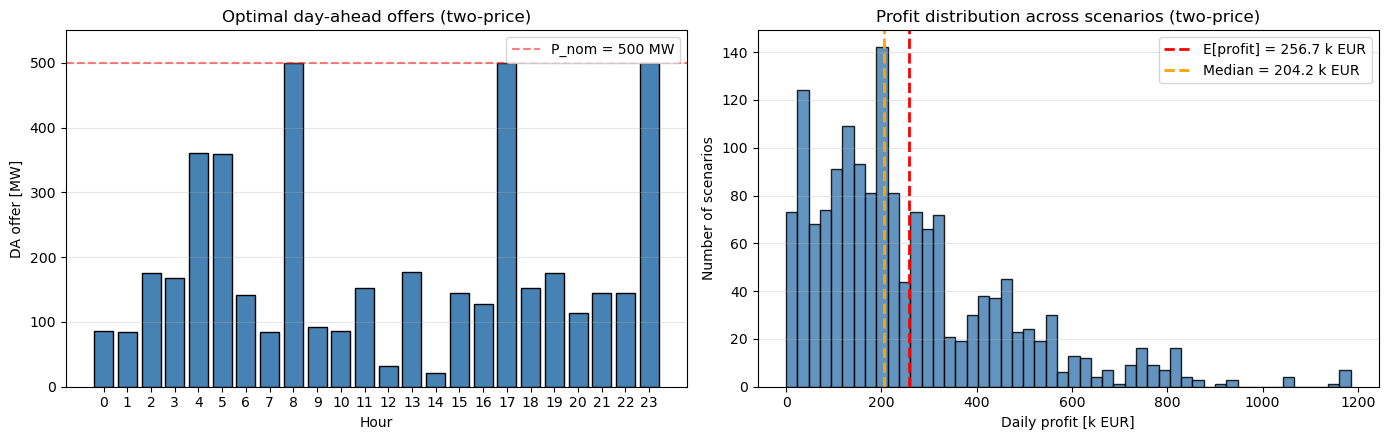

In [6]:
# Task 1.2 — Two-price offering strategy

from task1_2_offering_twoprice import TwoprcInputData, StochasticOfferingTwoPrice
from reporting import print_offering_summary, plot_offering_results

data_2p = TwoprcInputData(S)
res_2p = StochasticOfferingTwoPrice(data_2p).run()

print_offering_summary(res_2p, scheme_name="two-price")
print(f"\nComplementarity violations:    {res_2p.complementarity_violations} cells (well-posed bug check)")
print(f"Harmless degenerate cells:     {res_2p.harmless_degenerate_cells} cells (psi_up == psi_dn, in negative-price hours)")

fig, _ = plot_offering_results(res_2p, scheme_name="two-price", P_nom=S.P_nom)
plt.show()

# Task 1.3

In [7]:
# Task 1.3 — 8-fold cross-validation

from task1_3_cross_validation import run_8fold_cv

cv_1p = run_8fold_cv(S, scheme="one-price", seed=42)
cv_2p = run_8fold_cv(S, scheme="two-price", seed=42)

print()
print("Task 1.3 — 8-fold cross-validation (200 in-sample / 1400 out-of-sample)")
print()
print(f"\n{'Fold':<6} {'OnePrice IS':>14} {'OnePrice OOS':>14} {'TwoPrice IS':>14} {'TwoPrice OOS':>14}")
print("-" * 70)
for k in range(cv_1p.n_folds):
    print(f"{k+1:<6} "
          f"{cv_1p.in_sample_profits[k]:>14,.0f} "
          f"{cv_1p.out_sample_profits[k]:>14,.0f} "
          f"{cv_2p.in_sample_profits[k]:>14,.0f} "
          f"{cv_2p.out_sample_profits[k]:>14,.0f}")
print("-" * 70)
print(f"{'Mean':<6} "
      f"{cv_1p.mean_in_sample:>14,.0f} "
      f"{cv_1p.mean_out_sample:>14,.0f} "
      f"{cv_2p.mean_in_sample:>14,.0f} "
      f"{cv_2p.mean_out_sample:>14,.0f}")
print()
print(f"In-sample vs out-of-sample gap (one-price): {cv_1p.gap_pct:.2f}%")
print(f"In-sample vs out-of-sample gap (two-price): {cv_2p.gap_pct:.2f}%")


Task 1.3 — 8-fold cross-validation (200 in-sample / 1400 out-of-sample)


Fold      OnePrice IS   OnePrice OOS    TwoPrice IS   TwoPrice OOS
----------------------------------------------------------------------
1             312,951        310,829        260,993        255,877
2             295,014        313,391        235,646        259,412
3             297,861        312,984        245,473        258,177
4             324,436        309,188        269,672        254,582
5             307,204        311,649        254,828        256,775
6             338,253        307,214        282,701        252,747
7             311,589        311,023        258,514        256,319
8             301,443        312,472        247,273        258,008
----------------------------------------------------------------------
Mean          311,094        311,094        256,888        256,487

In-sample vs out-of-sample gap (one-price): -0.00%
In-sample vs out-of-sample gap (two-price): 0.16%


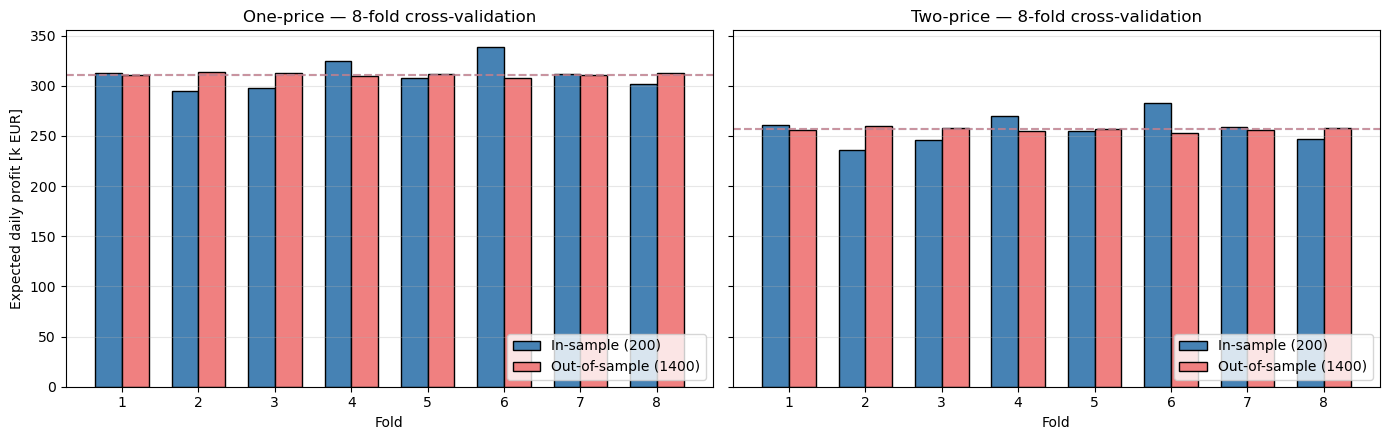

In [8]:
# Task 1.3 — plot

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)

for ax, cv, name in zip(axes, [cv_1p, cv_2p], ["One-price", "Two-price"]):
    folds = np.arange(1, cv.n_folds + 1)
    width = 0.35
    ax.bar(folds - width/2, cv.in_sample_profits / 1000, width,
           label="In-sample (200)", color="steelblue", edgecolor="black")
    ax.bar(folds + width/2, cv.out_sample_profits / 1000, width,
           label="Out-of-sample (1400)", color="lightcoral", edgecolor="black")
    ax.axhline(cv.mean_in_sample / 1000, color="steelblue", linestyle="--", alpha=0.6)
    ax.axhline(cv.mean_out_sample / 1000, color="lightcoral", linestyle="--", alpha=0.6)
    ax.set_xlabel("Fold")
    ax.set_xticks(folds)
    ax.set_title(f"{name} — 8-fold cross-validation")
    ax.legend(loc="lower right")
    ax.grid(axis="y", alpha=0.3)

axes[0].set_ylabel("Expected daily profit [k EUR]")

plt.tight_layout()
plt.show()

# Task 1.4

In [9]:
# Task 1.4 — Risk-averse offering with CVaR

from task1_4_risk_averse import sweep_beta

# Sweep beta from 0 (risk-neutral) to 1 (CVaR-only) in 11 steps
betas = np.linspace(0.0, 1.0, 11)
alpha = 0.90

print("Sweeping beta for one-price scheme...")
sweep_1p = sweep_beta(S, scheme="one-price", betas=betas, alpha=alpha)

print("Sweeping beta for two-price scheme...")
sweep_2p = sweep_beta(S, scheme="two-price", betas=betas, alpha=alpha)

print()
print("Task 1.4 — CVaR sweep (alpha = 0.90)")
print()
print(f"\n{'beta':>6} {'OnePrice E[p]':>16} {'OnePrice CVaR':>16} {'TwoPrice E[p]':>16} {'TwoPrice CVaR':>16}")
print("-" * 80)
for i, b in enumerate(betas):
    print(f"{b:>6.2f} "
          f"{sweep_1p['expected_profits'][i]:>16,.0f} "
          f"{sweep_1p['cvars'][i]:>16,.0f} "
          f"{sweep_2p['expected_profits'][i]:>16,.0f} "
          f"{sweep_2p['cvars'][i]:>16,.0f}")

Sweeping beta for one-price scheme...
Sweeping beta for two-price scheme...

Task 1.4 — CVaR sweep (alpha = 0.90)


  beta    OnePrice E[p]    OnePrice CVaR    TwoPrice E[p]    TwoPrice CVaR
--------------------------------------------------------------------------------
  0.00          311,094           -4,230          256,721             -370
  0.10          311,094           39,718          256,694           23,910
  0.20          311,094           39,718          256,626           24,252
  0.30          311,094           39,718          256,571           24,419
  0.40          311,094           39,718          256,474           24,613
  0.50          311,094           39,718          256,304           24,816
  0.60          311,094           39,718          255,710           25,296
  0.70          311,094           39,718          255,070           25,615
  0.80          311,094           39,718          254,251           25,898
  0.90          307,078           40,342          253

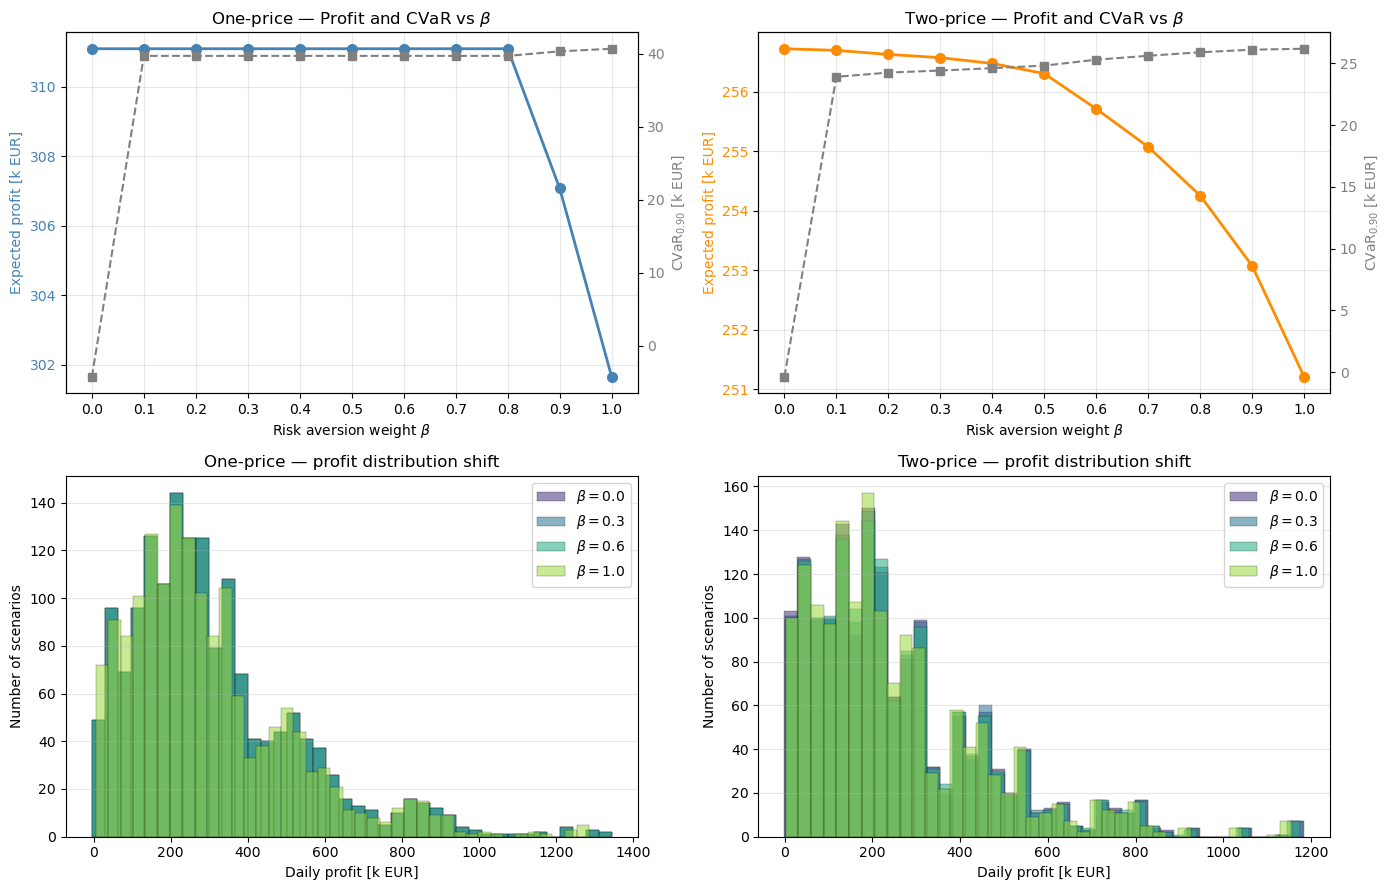

In [10]:
# Combined plot (Pareto frontiers + profit distributions)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# TOP ROW: Expected profit and CVaR as functions of beta
# (clearer than scatter Pareto when points collapse)
# -------------------------------------------------------

for ax, sweep, name, color in zip(
    axes[0, :], [sweep_1p, sweep_2p],
    ["One-price", "Two-price"], ["steelblue", "darkorange"]
):
    betas_arr = sweep['betas']
    profits_k = sweep['expected_profits'] / 1000
    cvars_k = sweep['cvars'] / 1000

    ax.plot(betas_arr, profits_k, 'o-', color=color, linewidth=2, markersize=7,
            label="Expected profit")
    ax2 = ax.twinx()
    ax2.plot(betas_arr, cvars_k, 's--', color='gray', linewidth=1.5, markersize=6,
             label=r"CVaR$_{0.90}$")

    ax.set_xlabel(r"Risk aversion weight $\beta$")
    ax.set_ylabel("Expected profit [k EUR]", color=color)
    ax2.set_ylabel(r"CVaR$_{0.90}$ [k EUR]", color='gray')
    ax.tick_params(axis='y', labelcolor=color)
    ax2.tick_params(axis='y', labelcolor='gray')
    ax.set_title(f"{name} — Profit and CVaR vs $\\beta$")
    ax.grid(alpha=0.3)
    ax.set_xticks(betas_arr)

# BOTTOM ROW: profit distributions for selected betas
# ----------------------------------------------------

selected_betas_idx = [0, 3, 6, 10]   # beta = 0.0, 0.3, 0.6, 1.0
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(selected_betas_idx)))

for ax, sweep, name in zip(
    axes[1, :], [sweep_1p, sweep_2p], ["One-price", "Two-price"]
):
    for c, idx in zip(colors, selected_betas_idx):
        beta = sweep['betas'][idx]
        profits = sweep['profits_per_scenario_per_beta'][idx] / 1000
        ax.hist(profits, bins=40, alpha=0.55, color=c,
                label=fr"$\beta={beta:.1f}$", edgecolor='black', linewidth=0.3)
    ax.set_xlabel("Daily profit [k EUR]")
    ax.set_ylabel("Number of scenarios")
    ax.set_title(f"{name} — profit distribution shift")
    ax.legend(loc='upper right')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Task 2.1


In [11]:
import sys
from pathlib import Path
import runpy

# Find the src folder that contains task2_1_fcrd_up.py
possible_src_paths = [
    Path.cwd() / "assignment_2" / "src",
    Path.cwd() / "src",
    Path.cwd().parent / "src",
    Path.cwd().parent / "assignment_2" / "src",
]

for path in possible_src_paths:
    if (path / "task2_1_fcrd_up.py").exists():
        sys.path.insert(0, str(path))
        task21_path = path / "task2_1_fcrd_up.py"
        print("Added src path:", path)
        break
else:
    raise FileNotFoundError("Could not find task2_1_fcrd_up.py")

# Run Task 2.1 script
task21 = runpy.run_path(str(task21_path), run_name="__main__")

Added src path: c:\Users\raula\Desktop\renewable\RES-Assignments\assignment_2\src
Minimum load: 220.023459506014
Maximum load: 599.9752540831429
Maximum minute-to-minute change: 35.00000000000006

   Method  Reserve bid [kW]  In-sample reliability  In-sample violation rate  \
0  ALSO-X          222.1461                   0.91                      0.09   
1    CVaR          221.1964                   0.95                      0.05   

   In-sample expected shortfall [kW]  
0                             0.0950  
1                             0.0317  


# Task 2.2

In [12]:
from task2_2_verification import run_task22

# Get Task 2.1 variables from the previous runpy execution
profiles_out = task21["profiles_out"]
R_alsox = float(task21["R_alsox"])
R_cvar = float(task21["R_cvar"])

task22_results = run_task22(
    profiles_out=profiles_out,
    R_alsox=R_alsox,
    R_cvar=R_cvar,
)

task22_results.round(4)

,Method,Reserve bid from Task 2.1 [kW],Out-of-sample reliability,Out-of-sample violation rate,Out-of-sample expected shortfall [kW],Number of violating profiles
0,ALSO-X,222.1461,0.92,0.08,0.1270,16
1,CVaR,221.1964,0.93,0.07,0.0528,14


# Task 2.3

In [13]:
from task2_3_en_pers import run_task23
from task2_1_fcrd_up import profiles_in, profiles_out

results_23 = run_task23(profiles_in, profiles_out)
results_23.round(4)

Minimum load: 220.023459506014
Maximum load: 599.9752540831429
Maximum minute-to-minute change: 35.00000000000006

   Method  Reserve bid [kW]  In-sample reliability  In-sample violation rate  \
0  ALSO-X          222.1461                   0.91                      0.09   
1    CVaR          221.1964                   0.95                      0.05   

   In-sample expected shortfall [kW]  
0                             0.0950  
1                             0.0317  


,Reliability requirement,Required reliability level,Optimal ALSO-X reserve bid [kW],In-sample reliability,In-sample violation rate,In-sample expected shortfall [kW],In-sample violating profiles,Out-of-sample reliability,Out-of-sample violation rate,Out-of-sample expected shortfall [kW],Out-of-sample violating profiles,Reserve bid reduction vs P80 [kW],Out-of-sample shortfall reduction vs P80 [kW]
0,P80,0.80,254.0630,0.81,0.19,5.8874,19,0.775,0.225,5.8528,45,0.0000,0.0000
1,P82,0.82,229.0523,0.82,0.18,1.1353,18,0.845,0.155,1.0272,31,25.0107,4.8256
2,P84,0.84,226.3181,0.84,0.16,0.6704,16,0.855,0.145,0.6220,29,27.7449,5.2308
3,P86,0.86,223.9613,0.86,0.14,0.2988,14,0.880,0.120,0.3025,24,30.1017,5.5503
4,P88,0.88,223.5323,0.88,0.12,0.2395,12,0.880,0.120,0.2510,24,30.5307,5.6018
5,P90,0.90,222.1461,0.91,0.09,0.0950,9,0.920,0.080,0.1270,16,31.9168,5.7257
6,P92,0.92,221.8516,0.93,0.07,0.0703,7,0.920,0.080,0.1035,16,32.2114,5.7493
7,P94,0.94,221.5667,0.94,0.06,0.0503,6,0.920,0.080,0.0807,16,32.4963,5.7721
8,P96,0.96,221.1498,0.96,0.04,0.0293,4,0.930,0.070,0.0496,14,32.9132,5.8032
9,P98,0.98,220.5837,0.98,0.02,0.0087,2,0.950,0.050,0.0124,10,33.4793,5.8403


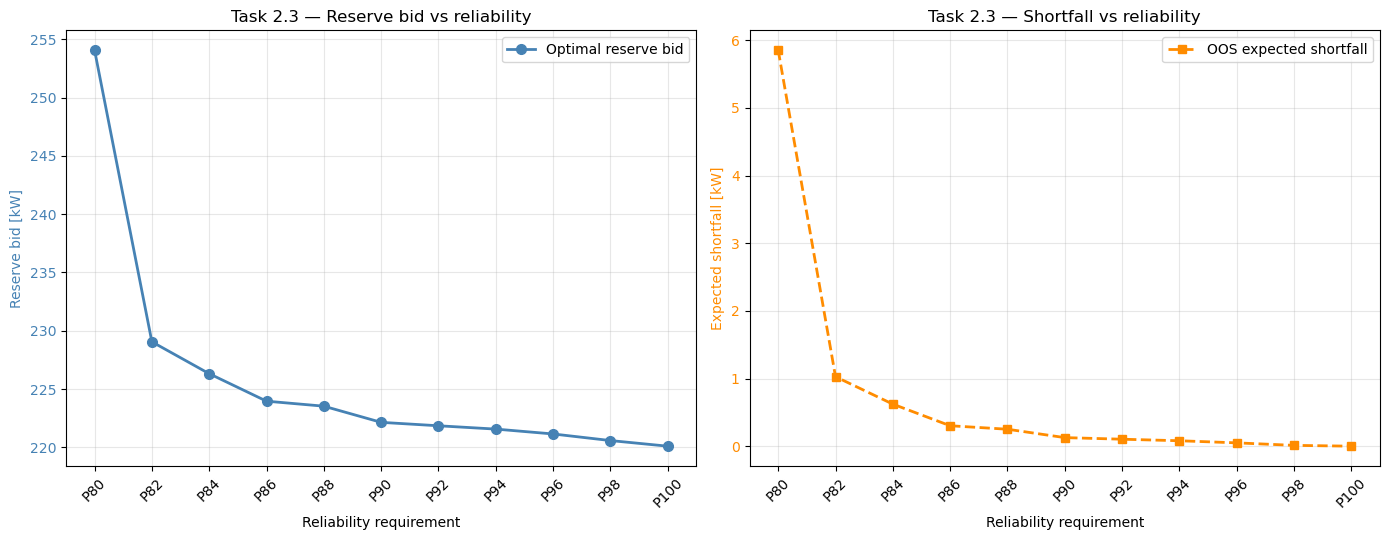

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Datos desde tu DataFrame
levels = results_23["Required reliability level"].values
labels = results_23["Reliability requirement"].values

reserve_bid = results_23["Optimal ALSO-X reserve bid [kW]"].values
shortfall = results_23["Out-of-sample expected shortfall [kW]"].values

# Combined plot: reserve bid + expected shortfall
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# LEFT: reserve bid vs reliability
ax = axes[0]
ax.plot(
    levels, reserve_bid,
    'o-', color='steelblue',
    linewidth=2, markersize=7,
    label="Optimal reserve bid"
)
ax.set_xlabel("Reliability requirement")
ax.set_ylabel("Reserve bid [kW]", color='steelblue')
ax.tick_params(axis='y', labelcolor='steelblue')
ax.set_title("Task 2.3 — Reserve bid vs reliability")
ax.set_xticks(levels)
ax.set_xticklabels(labels, rotation=45)
ax.grid(alpha=0.3)
ax.legend(loc='best')

# RIGHT: expected shortfall vs reliability
ax = axes[1]
ax.plot(
    levels, shortfall,
    's--', color='darkorange',
    linewidth=2, markersize=6,
    label="OOS expected shortfall"
)
ax.set_xlabel("Reliability requirement")
ax.set_ylabel("Expected shortfall [kW]", color='darkorange')
ax.tick_params(axis='y', labelcolor='darkorange')
ax.set_title("Task 2.3 — Shortfall vs reliability")
ax.set_xticks(levels)
ax.set_xticklabels(labels, rotation=45)
ax.grid(alpha=0.3)
ax.legend(loc='best')

plt.tight_layout()
plt.show()

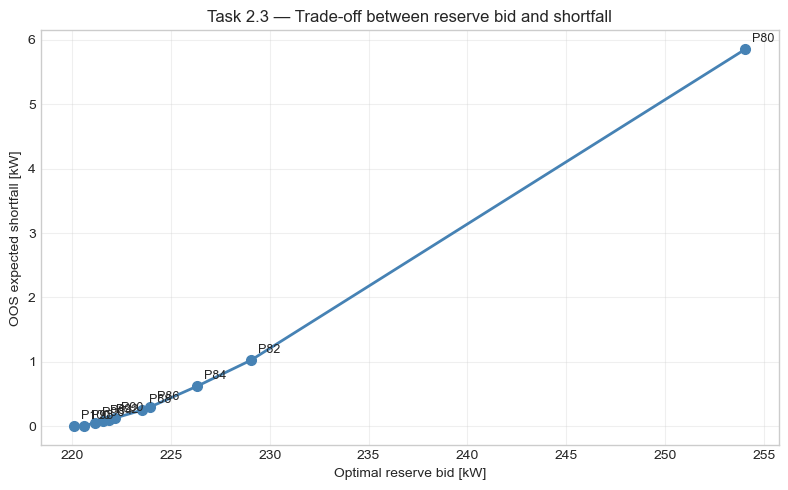

In [15]:
import matplotlib.pyplot as plt

x = results_23["Optimal ALSO-X reserve bid [kW]"]
y = results_23["Out-of-sample expected shortfall [kW]"]
labels = results_23["Reliability requirement"]

plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x, y, 'o-', color='steelblue', linewidth=2, markersize=7)

for xi, yi, lab in zip(x, y, labels):
    ax.annotate(lab, (xi, yi), textcoords="offset points", xytext=(5, 5), fontsize=9)

ax.set_xlabel("Optimal reserve bid [kW]")
ax.set_ylabel("OOS expected shortfall [kW]")
ax.set_title("Task 2.3 — Trade-off between reserve bid and shortfall")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()